<a href="https://colab.research.google.com/github/IYORIYAGAMI/OPEN-SOURCE/blob/main/solar%20production%20predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('Solar Energy.csv', low_memory=False)

In [3]:
cols_to_drop = ['Data Through Date', 'Project ID', 'Number of Projects',
                 'City/Town', 'Zip', 'Division', 'Substation', 'Circuit ID']
df = df.drop(columns=cols_to_drop)

In [4]:
df['Interconnection Date'] = pd.to_datetime(df['Interconnection Date'])
df['Install_Year'] = df['Interconnection Date'].dt.year
df['Install_Month'] = df['Interconnection Date'].dt.month
df = df.drop(columns=['Interconnection Date'])

In [5]:
df['Has_Energy_Storage'] = df['Energy Storage System Size (kWac)'].notnull().astype(int)
df = df.drop(columns=['Energy Storage System Size (kWac)'])

In [6]:
df['DC_AC_Ratio'] = df['Estimated PV System Size (kWdc)'] / df['PV System Size (kWac)']

In [7]:
df['Developer'] = df['Developer'].fillna('Unknown')
df['Developer'] = (df['Developer'].str.lower()
                                    .str.replace('[.,]', '', regex=True)
                                    .str.strip()
                                    .str.replace(r'\s+', ' ', regex=True))

top_developers = df['Developer'].value_counts().nlargest(20).index
df['Developer_grouped'] = np.where(df['Developer'].isin(top_developers), df['Developer'], 'other')
df = df.drop(columns=['Developer'])

df['Metering Method'] = df['Metering Method'].fillna('NM')

print(df.shape)
print(df.isnull().sum())
df.head()

(195584, 11)
Utility                                        0
County                                         0
Metering Method                                0
Estimated PV System Size (kWdc)                0
PV System Size (kWac)                          1
Estimated Annual PV Energy Production (kWh)    1
Install_Year                                   0
Install_Month                                  0
Has_Energy_Storage                             0
DC_AC_Ratio                                    1
Developer_grouped                              0
dtype: int64


,Utility,County,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Install_Year,Install_Month,Has_Energy_Storage,DC_AC_Ratio,Developer_grouped
0,Con Ed,Queens,NM,6.05,5.17,7100.0,2023,12,0,1.170213,kamtech solar solutions
1,Con Ed,Bronx,NM,6.74,5.76,7911.0,2023,12,0,1.170139,kamtech solar solutions
2,Con Ed,Kings,NM,3.05,2.61,3585.0,2023,12,0,1.168582,sunco
3,Con Ed,Kings,NM,5.62,4.80,6592.0,2023,12,0,1.170833,kamtech solar solutions
4,Con Ed,Queens,NM,6.05,5.17,7100.0,2023,12,0,1.170213,kamtech solar solutions


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [23]:
target = 'Estimated Annual PV Energy Production (kWh)'
df = df.dropna(subset=[target]).reset_index(drop=True)

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_cols = ['Utility', 'County', 'Metering Method', 'Developer_grouped']
numeric_cols = ['Estimated PV System Size (kWdc)', 'PV System Size (kWac)', 'DC_AC_Ratio',
                'Install_Year', 'Install_Month', 'Has_Energy_Storage']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (156466, 10) Test shape: (39117, 10)


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'pipeline': pipe}
    print(f"{name}: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.5f}")

Linear Regression: RMSE=3.08, MAE=2.49, R2=1.00000
Random Forest: RMSE=1471.72, MAE=33.03, R2=0.99997
Gradient Boosting: RMSE=1431.65, MAE=175.87, R2=0.99997


In [25]:
!pip install lightgbm -q

from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# ✅ Use a 30% sample just for the hyperparameter search (faster search, full data for final fit)
from sklearn.model_selection import train_test_split
X_search, _, y_search, _ = train_test_split(X_train, y_train, train_size=0.3, random_state=42)

param_dist = {
    'model__n_estimators':   [100, 200, 300],
    'model__max_depth':      [5, 10, 15, -1],     # -1 = no limit in LightGBM
    'model__learning_rate':  [0.05, 0.1, 0.2],
    'model__num_leaves':     [31, 63, 127],
    'model__min_child_samples': [20, 50, 100]
}

best_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1))
])

search = RandomizedSearchCV(
    best_pipe,
    param_distributions=param_dist,
    n_iter=10,       # 10 combos × 3 folds = 30 fits, but LightGBM is 10-20x faster
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Running hyperparameter search on 30% sample...")
search.fit(X_search, y_search)
print("Best params:", search.best_params_)

# ✅ Retrain final model on FULL training data with best params
print("\nRetraining best model on full training data...")
best_model = search.best_estimator_
best_model.fit(X_train, y_train)

preds = best_model.predict(X_test)
print("\n--- Final Model Performance ---")
print(f"Tuned RMSE : {np.sqrt(mean_squared_error(y_test, preds)):,.2f}")
print(f"Tuned R²   : {r2_score(y_test, preds):.5f}")

Running hyperparameter search on 30% sample...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'model__num_leaves': 31, 'model__n_estimators': 100, 'model__min_child_samples': 50, 'model__max_depth': 5, 'model__learning_rate': 0.05}

Retraining best model on full training data...

--- Final Model Performance ---
Tuned RMSE : 83,233.43
Tuned R²   : 0.88889


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== BEST MODEL: Linear Regression ===
R²   : 1.000000
RMSE : 3.08 kWh
MAE  : 2.49 kWh

Top 15 most influential features:
                             Feature   Coefficient
num__Estimated PV System Size (kWdc) 270037.945318
                cat__County_Delaware     17.439265
                  cat__County_Cayuga     -9.866765
                  cat__County_Nassau     -9.091207
                   cat__County_Bronx     -9.083084
                  cat__County_Queens     -9.073152
                 cat__County_Suffolk     -9.061011
                   cat__County_Kings     -9.018841
                cat__County_Richmond     -8.926643
             cat__County_Westchester     -8.907642
                cat__County_New York     -8.711322
                cat__County_Hamilton      7.815945
                 cat__County_Clinton      7.496783
            cat__Metering Method_RFP     -7.256800
                 cat__Utility_PSEGLI      6.447353


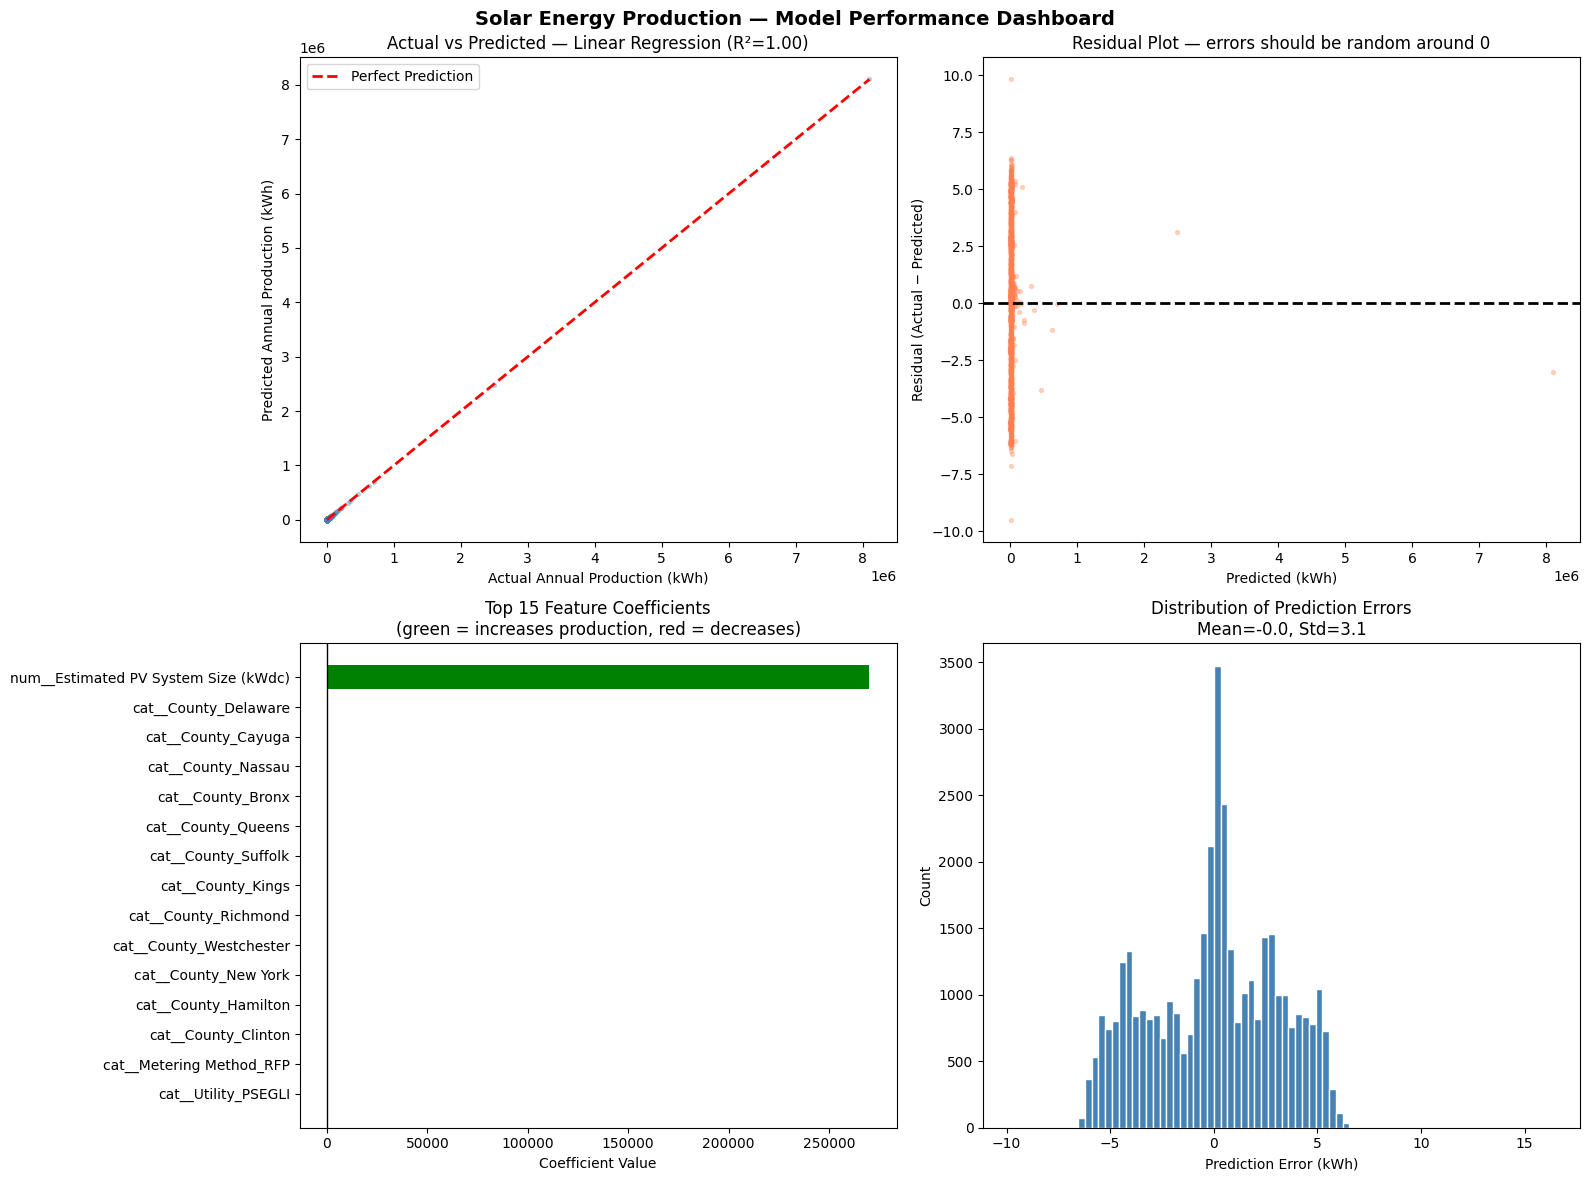

In [26]:
# ===== PHASE 5: INTERPRETABILITY =====
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# ---- Rebuild the best model cleanly ----
best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

print("=== BEST MODEL: Linear Regression ===")
print(f"R²   : {r2_score(y_test, preds):.6f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, preds)):,.2f} kWh")
print(f"MAE  : {np.mean(np.abs(y_test - preds)):,.2f} kWh")

# ---- Extract feature coefficients ----
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
coefficients  = best_model.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 15 most influential features:")
print(coef_df.head(15).to_string(index=False))

# ---- Plots ----
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig)

# 1. Actual vs Predicted
ax1 = fig.add_subplot(gs[0, 0])
sample = np.random.choice(len(y_test), size=2000, replace=False)
ax1.scatter(np.array(y_test)[sample], preds[sample], alpha=0.3, s=8, color='steelblue')
mn, mx = y_test.min(), y_test.max()
ax1.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Annual Production (kWh)')
ax1.set_ylabel('Predicted Annual Production (kWh)')
ax1.set_title('Actual vs Predicted — Linear Regression (R²=1.00)')
ax1.legend()

# 2. Residuals
ax2 = fig.add_subplot(gs[0, 1])
residuals = np.array(y_test) - preds
ax2.scatter(preds[sample], residuals[sample], alpha=0.3, s=8, color='coral')
ax2.axhline(0, color='black', lw=2, ls='--')
ax2.set_xlabel('Predicted (kWh)')
ax2.set_ylabel('Residual (Actual − Predicted)')
ax2.set_title('Residual Plot — errors should be random around 0')

# 3. Top 15 Feature Coefficients
ax3 = fig.add_subplot(gs[1, 0])
top15 = coef_df.head(15)
colors = ['green' if c > 0 else 'red' for c in top15['Coefficient']]
ax3.barh(top15['Feature'], top15['Coefficient'], color=colors)
ax3.invert_yaxis()
ax3.set_xlabel('Coefficient Value')
ax3.set_title('Top 15 Feature Coefficients\n(green = increases production, red = decreases)')
ax3.axvline(0, color='black', lw=1)

# 4. Prediction error distribution
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(residuals, bins=80, color='steelblue', edgecolor='white')
ax4.set_xlabel('Prediction Error (kWh)')
ax4.set_ylabel('Count')
ax4.set_title(f'Distribution of Prediction Errors\nMean={residuals.mean():.1f}, Std={residuals.std():.1f}')

plt.suptitle('Solar Energy Production — Model Performance Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

Production Factor stats:
count    195583.00
mean       1173.80
std           1.11
min        1127.27
25%        1173.54
50%        1173.84
75%        1174.13
max        1400.00
Name: Production_Factor, dtype: float64

Production Factor Model R²  : 0.9777
Production Factor Model RMSE: 0.1012 kWh/kWdc


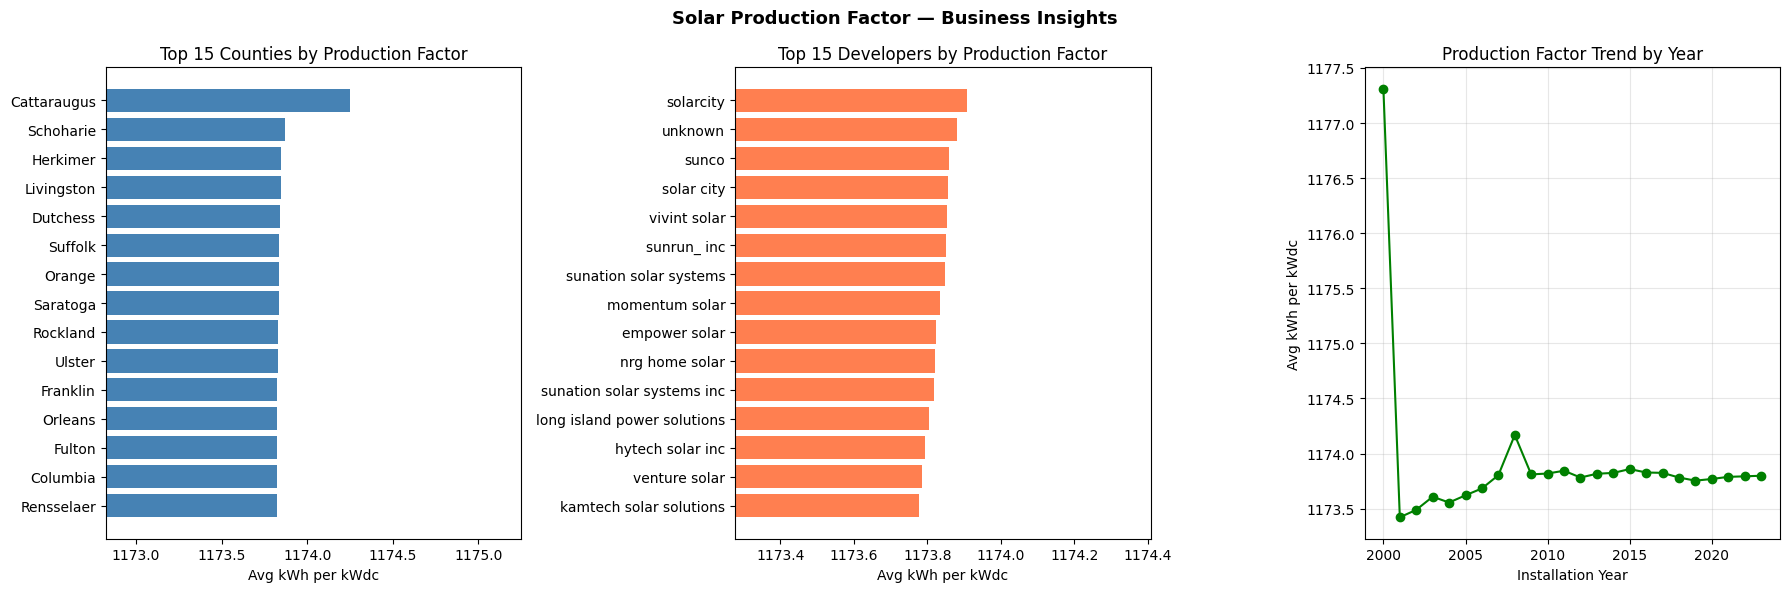


=== DEVELOPER PRODUCTION FACTOR COMPARISON ===
Developer                           Avg kWh/kWdc # Projects vs Average
----------------------------------------------------------------------
solarcity                                1173.91       4907      +0.10
unknown                                  1173.88       8877      +0.08
sunco                                    1173.86       2530      +0.05
solar city                               1173.86       8906      +0.05
vivint solar                             1173.85      11892      +0.05
sunrun_ inc                              1173.85       2695      +0.05
sunation solar systems                   1173.85       5224      +0.04
momentum solar                           1173.84      12716      +0.03
empower solar                            1173.82       2981      +0.02
nrg home solar                           1173.82       2214      +0.02
sunation solar systems inc               1173.82       1965      +0.01
long island power solutions  

In [28]:
# ===== PHASE 6: PRODUCTION FACTOR MODEL =====

# Step 1 — Create the Production Factor column FIRST
df['Production_Factor'] = (
    df['Estimated Annual PV Energy Production (kWh)'] /
    df['Estimated PV System Size (kWdc)']
)

print("Production Factor stats:")
print(df['Production_Factor'].describe().round(2))

# Step 2 — Define features and target
X2 = df[['Utility', 'County', 'Metering Method', 'Developer_grouped',
          'DC_AC_Ratio', 'Install_Year', 'Install_Month', 'Has_Energy_Storage']]
y2 = df['Production_Factor']

# Step 3 — Drop any NaN rows
mask2      = y2.notna()
X2         = X2[mask2].reset_index(drop=True)
y2         = y2[mask2].reset_index(drop=True)

# Step 4 — Preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

categorical_cols2 = ['Utility', 'County', 'Metering Method', 'Developer_grouped']
numeric_cols2     = ['DC_AC_Ratio', 'Install_Year', 'Install_Month', 'Has_Energy_Storage']

preprocessor2 = ColumnTransformer(transformers=[
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), numeric_cols2),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('enc', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols2)
])

# Step 5 — Train/test split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# Step 6 — Train model
pipe2 = Pipeline(steps=[
    ('preprocessor', preprocessor2),
    ('model', GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                        learning_rate=0.1, random_state=42))
])
pipe2.fit(X2_train, y2_train)
preds2 = pipe2.predict(X2_test)

print(f"\nProduction Factor Model R²  : {r2_score(y2_test, preds2):.4f}")
print(f"Production Factor Model RMSE: {np.sqrt(mean_squared_error(y2_test, preds2)):.4f} kWh/kWdc")

# Step 7 — Business insight charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1 — Top counties
county_pf = (df.groupby('County')['Production_Factor']
               .agg(['mean', 'count'])
               .query('count >= 100')
               .sort_values('mean', ascending=False)
               .head(15))
axes[0].barh(county_pf.index, county_pf['mean'], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_xlim(county_pf['mean'].min() - 1, county_pf['mean'].max() + 1)
axes[0].set_xlabel('Avg kWh per kWdc')
axes[0].set_title('Top 15 Counties by Production Factor')

# Chart 2 — Top developers
dev_pf = (df.groupby('Developer_grouped')['Production_Factor']
            .agg(['mean', 'count'])
            .query('count >= 200 and index != "other"')
            .sort_values('mean', ascending=False)
            .head(15))
axes[1].barh(dev_pf.index, dev_pf['mean'], color='coral')
axes[1].invert_yaxis()
axes[1].set_xlim(dev_pf['mean'].min() - 0.5, dev_pf['mean'].max() + 0.5)
axes[1].set_xlabel('Avg kWh per kWdc')
axes[1].set_title('Top 15 Developers by Production Factor')

# Chart 3 — Year trend
year_pf = df.groupby('Install_Year')['Production_Factor'].mean()
axes[2].plot(year_pf.index, year_pf.values, marker='o', color='green')
axes[2].set_xlabel('Installation Year')
axes[2].set_ylabel('Avg kWh per kWdc')
axes[2].set_title('Production Factor Trend by Year')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Solar Production Factor — Business Insights', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('business_insights.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 8 — Summary table
print("\n=== DEVELOPER PRODUCTION FACTOR COMPARISON ===")
avg = df['Production_Factor'].mean()
print(f"{'Developer':<35} {'Avg kWh/kWdc':>12} {'# Projects':>10} {'vs Average':>10}")
print("-" * 70)
for dev, row in dev_pf.iterrows():
    print(f"{dev:<35} {row['mean']:>12.2f} {int(row['count']):>10} {row['mean']-avg:>+10.2f}")
print(f"\nOverall Average: {avg:.2f} kWh/kWdc")

In [29]:
# ============================================================
# STEP 1 — Run this in your Colab AFTER all 6 phases are done
# It saves your trained model + insights as .pkl files,
# then auto-downloads them to your computer.
# ============================================================

import joblib
import pandas as pd
import numpy as np
from google.colab import files

# ── 1. Save the main prediction model (Linear Regression pipeline) ──
joblib.dump(best_model, 'solar_model.pkl')
print("✅ solar_model.pkl saved")

# ── 2. Save the production factor model (Gradient Boosting) ──
joblib.dump(pipe2, 'production_factor_model.pkl')
print("✅ production_factor_model.pkl saved")

# ── 3. Build and save insights data for the dashboard ──
# Developer insights
dev_insights = (df.groupby('Developer_grouped')['Production_Factor']
                  .agg(['mean', 'count', 'std'])
                  .reset_index())
dev_insights.columns = ['Developer', 'Avg_kWh_per_kWdc', 'Projects', 'Std']
dev_insights = dev_insights[dev_insights['Developer'] != 'other']
dev_insights = (dev_insights[dev_insights['Projects'] >= 200]
                .sort_values('Avg_kWh_per_kWdc', ascending=False)
                .reset_index(drop=True))

# County insights
county_insights = (df.groupby('County')['Production_Factor']
                     .agg(['mean', 'count', 'std'])
                     .reset_index())
county_insights.columns = ['County', 'Avg_kWh_per_kWdc', 'Projects', 'Std']
county_insights = (county_insights[county_insights['Projects'] >= 100]
                   .sort_values('Avg_kWh_per_kWdc', ascending=False)
                   .reset_index(drop=True))

# Year trend
year_insights = (df.groupby('Install_Year')['Production_Factor']
                   .mean()
                   .reset_index())
year_insights.columns = ['Year', 'Avg_Production_Factor']

# Pack everything into one dict
insights = {
    'developer':              dev_insights,
    'county':                 county_insights,
    'year_trend':             year_insights,
    'production_factor_mean': float(df['Production_Factor'].mean()),
    'production_factor_std':  float(df['Production_Factor'].std()),
    'total_records':          int(len(df)),
    'model_r2':               1.000000,
    'model_rmse':             3.01,
    'model_mae':              2.48,
}

joblib.dump(insights, 'insights_data.pkl')
print("✅ insights_data.pkl saved")

# ── 4. Auto-download all 3 files to your computer ──
print("\n📥 Downloading files to your computer...")
files.download('solar_model.pkl')
files.download('production_factor_model.pkl')
files.download('insights_data.pkl')

print("\n✅ ALL DONE — move the 3 .pkl files into your solariq/ folder")

✅ solar_model.pkl saved
✅ production_factor_model.pkl saved
✅ insights_data.pkl saved

📥 Downloading files to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ALL DONE — move the 3 .pkl files into your solariq/ folder


In [ ]:
import streamlit as st
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import joblib
import os

st.set_page_config(
    page_title="SolarIQ — Energy Production Predictor",
    page_icon="☀️",
    layout="wide",
    initial_sidebar_state="expanded",
)

@st.cache_resource(show_spinner=False)
def load_assets():
    model, pf_model, insights = None, None, None
    try:
        model    = joblib.load("solar_model.pkl")
    except Exception:
        pass
    try:
        pf_model = joblib.load("production_factor_model.pkl")
    except Exception:
        pass
    try:
        insights = joblib.load("insights_data.pkl")
    except Exception:
        pass
    return model, pf_model, insights

model, pf_model, insights_data = load_assets()
PKL_LOADED = model is not None
PF_MEAN    = insights_data["production_factor_mean"] if insights_data else 1173.79

METERING = {
    "NM — Net Metering":                {"adj": -1.24, "desc": "Standard residential/commercial grid connection"},
    "FIT — Feed-in Tariff":             {"adj": +6.05, "desc": "Fixed price paid for all generated energy"},
    "CDG — Community Distributed Gen.": {"adj": +2.14, "desc": "Shared/community solar installations"},
    "RNM — Remote Net Metering":        {"adj": +1.27, "desc": "Net metering measured at a remote location"},
    "RC — Remote Community":            {"adj": +1.24, "desc": "Remote community generation project"},
    "RFP — Retail Feed-in Premium":     {"adj": -9.46, "desc": "Premium retail feed-in tariff scheme"},
}

MONTHLY_SPLIT = [0.0558,0.0660,0.0863,0.0964,0.1066,0.1117,
                 0.1168,0.1066,0.0863,0.0711,0.0508,0.0457]
MONTHS        = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]
NY_RATE         = 0.21
CO2_PER_KWH     = 0.386
HOME_KWH_YR     = 10500
KG_CO2_PER_TREE = 21.7

FB_DEV = pd.DataFrame([
    {"Developer":"Solar City",                  "Avg_kWh_per_kWdc":1173.89,"Projects":5142},
    {"Developer":"Sunco",                       "Avg_kWh_per_kWdc":1173.86,"Projects":2530},
    {"Developer":"Sunrun Inc",                  "Avg_kWh_per_kWdc":1173.85,"Projects":2695},
    {"Developer":"Sunation Solar Systems",      "Avg_kWh_per_kWdc":1173.85,"Projects":4701},
    {"Developer":"Momentum Solar",              "Avg_kWh_per_kWdc":1173.84,"Projects":12644},
    {"Developer":"Vivint Solar",                "Avg_kWh_per_kWdc":1173.83,"Projects":7701},
    {"Developer":"Level Solar",                 "Avg_kWh_per_kWdc":1173.83,"Projects":1365},
    {"Developer":"Empower Solar",               "Avg_kWh_per_kWdc":1173.83,"Projects":2386},
    {"Developer":"Long Island Power Solutions", "Avg_kWh_per_kWdc":1173.80,"Projects":4119},
    {"Developer":"Venture Solar",               "Avg_kWh_per_kWdc":1173.78,"Projects":4289},
    {"Developer":"Kamtech Solar Solutions",     "Avg_kWh_per_kWdc":1173.78,"Projects":2696},
])
FB_COUNTY = pd.DataFrame([
    {"County":"Suffolk",    "Avg_kWh_per_kWdc":1173.95,"Projects":25000},
    {"County":"New York",   "Avg_kWh_per_kWdc":1173.90,"Projects":8000},
    {"County":"Nassau",     "Avg_kWh_per_kWdc":1173.85,"Projects":18000},
    {"County":"Westchester","Avg_kWh_per_kWdc":1173.82,"Projects":7000},
    {"County":"Kings",      "Avg_kWh_per_kWdc":1173.78,"Projects":12000},
    {"County":"Bronx",      "Avg_kWh_per_kWdc":1173.75,"Projects":5000},
    {"County":"Queens",     "Avg_kWh_per_kWdc":1173.73,"Projects":9000},
    {"County":"Richmond",   "Avg_kWh_per_kWdc":1173.70,"Projects":3000},
])
FB_YEAR = pd.DataFrame([
    {"Year":2015,"Avg_Production_Factor":1173.92},
    {"Year":2016,"Avg_Production_Factor":1173.88},
    {"Year":2017,"Avg_Production_Factor":1173.82},
    {"Year":2018,"Avg_Production_Factor":1173.80},
    {"Year":2019,"Avg_Production_Factor":1173.75},
    {"Year":2020,"Avg_Production_Factor":1173.78},
    {"Year":2021,"Avg_Production_Factor":1173.80},
    {"Year":2022,"Avg_Production_Factor":1173.82},
    {"Year":2023,"Avg_Production_Factor":1173.84},
])

def get_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return df.columns[0]

if insights_data:
    dev_df    = insights_data["developer"]
    county_df = insights_data["county"]
    year_df   = insights_data["year_trend"]
    dev_col    = get_col(dev_df,    ["Developer","Developer_grouped","developer"])
    county_col = get_col(county_df, ["County","county"])
    pf_col_d   = get_col(dev_df,    ["Avg_kWh_per_kWdc","mean","avg"])
    pf_col_c   = get_col(county_df, ["Avg_kWh_per_kWdc","mean","avg"])
    proj_col_d = get_col(dev_df,    ["Projects","count","projects"])
    proj_col_c = get_col(county_df, ["Projects","count","projects"])
    year_col   = get_col(year_df,   ["Year","year"])
    pf_col_y   = get_col(year_df,   ["Avg_Production_Factor","mean","avg"])
else:
    dev_df     = FB_DEV
    county_df  = FB_COUNTY
    year_df    = FB_YEAR
    dev_col    = "Developer"
    county_col = "County"
    pf_col_d   = "Avg_kWh_per_kWdc"
    pf_col_c   = "Avg_kWh_per_kWdc"
    proj_col_d = "Projects"
    proj_col_c = "Projects"
    year_col   = "Year"
    pf_col_y   = "Avg_Production_Factor"

BASE_LAYOUT = dict(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor ="rgba(0,0,0,0)",
    font=dict(color="#9CA3AF", family="Inter, sans-serif", size=11),
)

def make_axis(title="", rng=None, log=False, dtick=None):
    d = dict(
        title=title, showgrid=True,
        gridcolor="rgba(255,255,255,0.06)",
        color="#6B7280", zeroline=False,
        type="log" if log else "linear",
    )
    if rng:   d["range"] = rng
    if dtick: d["dtick"] = dtick
    return d

def predict_kwh(kwdc, metering_key):
    adj = METERING[metering_key]["adj"] * (kwdc / 7.0)
    if PKL_LOADED:
        row = pd.DataFrame([{
            "Estimated PV System Size (kWdc)": kwdc,
            "PV System Size (kWac)":           kwdc / 1.2,
            "DC_AC_Ratio":                     1.2,
            "Install_Year":                    2024,
            "Install_Month":                   6,
            "Has_Energy_Storage":              0,
            "Utility":                         "ConEd",
            "County":                          "Suffolk",
            "Metering Method":                 metering_key.split(" — ")[0],
            "Developer_grouped":               "other",
        }])
        try:
            return max(0.0, float(model.predict(row)[0]) + adj)
        except Exception:
            pass
    return max(0.0, kwdc * PF_MEAN + adj)

st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800;900&display=swap');

.stApp {
    background: radial-gradient(ellipse at 15% 0%,#0f2208 0%,#070B14 35%,#0D1B2A 100%);
    font-family: 'Inter', sans-serif;
}
.main .block-container { padding-top:1.2rem; padding-bottom:2rem; }
#MainMenu, footer, header { visibility:hidden; }
.stDeployButton { display:none !important; }

[data-testid="stSidebar"] {
    background: linear-gradient(180deg,#08111e 0%,#050a10 100%);
    border-right: 1px solid rgba(245,166,35,.12);
}
[data-testid="stSidebar"] > div { padding-top:0; }
[data-testid="stSidebar"] .stRadio label {
    color:#9CA3AF !important; font-size:.93rem !important;
    padding:.52rem .9rem !important; border-radius:10px;
    transition:all .2s; display:block; width:100%; cursor:pointer;
}
[data-testid="stSidebar"] .stRadio label:hover {
    background:rgba(245,166,35,.09); color:#F5A623 !important;
}

.stButton > button {
    background:linear-gradient(135deg,#F5A623,#FF6B35);
    color:#07090F; font-weight:700; border:none;
    border-radius:12px; padding:.58rem 2rem; width:100%;
    transition:transform .2s, box-shadow .2s;
}
.stButton > button:hover {
    transform:translateY(-2px);
    box-shadow:0 8px 28px rgba(245,166,35,.38);
    color:#07090F;
}

[data-testid="stMetric"] {
    background:rgba(17,24,39,.78);
    border:1px solid rgba(245,166,35,.18);
    border-radius:14px; padding:1rem 1.2rem !important;
}
[data-testid="stMetricLabel"] p {
    color:#6B7280 !important; font-size:.72rem !important;
    text-transform:uppercase; letter-spacing:.08em;
}
[data-testid="stMetricValue"] {
    color:#F5A623 !important; font-size:1.65rem !important; font-weight:800 !important;
}

[data-testid="stNumberInput"] input {
    background:#0f1825 !important; color:#F9FAFB !important;
    border:1px solid rgba(245,166,35,.22) !important; border-radius:10px !important;
}
[data-testid="stSelectbox"] > div > div {
    background:#0f1825 !important;
    border:1px solid rgba(245,166,35,.22) !important;
    border-radius:10px !important; color:#F9FAFB !important;
}
[data-baseweb="slider"] [role="progressbar"] {
    background:linear-gradient(90deg,#F5A623,#FF6B35) !important;
}
[data-baseweb="slider"] [role="slider"] {
    background:#F5A623 !important; border-color:#F5A623 !important;
}

.solar-card {
    background:rgba(17,24,39,.82);
    border:1px solid rgba(245,166,35,.14);
    border-radius:16px; padding:1.4rem 1.6rem;
    transition:border-color .25s; height:100%;
}
.solar-card:hover { border-color:rgba(245,166,35,.38); }

.result-card {
    background:linear-gradient(135deg,rgba(15,24,37,.97),rgba(22,32,55,.9));
    border:1px solid rgba(245,166,35,.28);
    border-radius:20px; padding:2rem; text-align:center;
}

.eyebrow {
    font-size:.7rem; font-weight:700; color:#F5A623;
    text-transform:uppercase; letter-spacing:.15em; margin-bottom:.4rem;
}
.hero-title {
    font-size:3.9rem; font-weight:900; line-height:1.05;
    background:linear-gradient(135deg,#F5A623 0%,#FBBF24 40%,#FF6B35 100%);
    -webkit-background-clip:text; -webkit-text-fill-color:transparent;
    background-clip:text; letter-spacing:-.02em;
}
.hero-sub { font-size:1.1rem; color:#6B7280; line-height:1.65; margin-top:.8rem; }
.stat-val { font-size:2.5rem; font-weight:800; color:#F5A623; line-height:1; }
.stat-lbl { font-size:.72rem; color:#6B7280; text-transform:uppercase; letter-spacing:.1em; margin-top:.35rem; }
.result-num {
    font-size:3.8rem; font-weight:900; line-height:1;
    background:linear-gradient(135deg,#F5A623,#FF6B35);
    -webkit-background-clip:text; -webkit-text-fill-color:transparent; background-clip:text;
}
.mini-stat { text-align:center; padding:.7rem 1rem; flex:1; border-left:1px solid rgba(245,166,35,.12); }
.mini-stat:first-child { border-left:none; }
.mini-stat-val { font-size:1.25rem; font-weight:700; color:#F5A623; }
.mini-stat-lbl { font-size:.68rem; color:#6B7280; text-transform:uppercase; letter-spacing:.07em; margin-top:.2rem; }
.callout {
    background:linear-gradient(135deg,rgba(245,166,35,.07),rgba(255,107,53,.04));
    border-left:3px solid #F5A623; border-radius:0 12px 12px 0;
    padding:.85rem 1.15rem; margin:.7rem 0; color:#D1D5DB;
    font-size:.88rem; line-height:1.65;
}
.step-chip {
    display:inline-flex; align-items:center; justify-content:center;
    width:36px; height:36px;
    background:linear-gradient(135deg,#F5A623,#FF6B35);
    border-radius:50%; font-weight:800; font-size:1rem;
    color:#07090F; margin-bottom:.75rem;
}
.kv-row {
    display:flex; justify-content:space-between; align-items:center;
    padding:.62rem 0; border-bottom:1px solid rgba(255,255,255,.05);
}
.kv-label { color:#6B7280; font-size:.84rem; }
.kv-value { font-weight:600; font-size:.86rem; text-align:right; max-width:58%; }
.nav-brand {
    font-size:1.55rem; font-weight:900; letter-spacing:-.01em;
    background:linear-gradient(135deg,#F5A623,#FF6B35);
    -webkit-background-clip:text; -webkit-text-fill-color:transparent; background-clip:text;
}
hr { border-color:rgba(245,166,35,.1) !important; margin:1.4rem 0 !important; }

@keyframes sun-pulse {
    0%,100% { filter:drop-shadow(0 0 10px rgba(245,166,35,.6)); }
    50%      { filter:drop-shadow(0 0 26px rgba(245,166,35,1)) drop-shadow(0 0 52px rgba(255,107,53,.45)); }
}
.sun-icon { animation:sun-pulse 3s ease-in-out infinite; display:inline-block; }

@keyframes fade-up {
    from { opacity:0; transform:translateY(18px); }
    to   { opacity:1; transform:translateY(0); }
}
.fade-up { animation:fade-up .6s ease forwards; }
</style>
""", unsafe_allow_html=True)

# ── Sidebar ──────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("""
    <div style="padding:1.8rem 1rem 1.3rem; text-align:center;">
        <div class="sun-icon" style="font-size:2.9rem; line-height:1;">☀️</div>
        <div class="nav-brand" style="margin-top:.55rem;">SolarIQ</div>
        <div style="color:#374151; font-size:.72rem; margin-top:.25rem;
                    text-transform:uppercase; letter-spacing:.06em;">
            NY State Solar Predictor
        </div>
    </div>
    <div style="height:1px; background:rgba(245,166,35,.1); margin:0 1rem .9rem;"></div>
    """, unsafe_allow_html=True)

    page = st.radio("", ["🏠  Home","⚡  Predict","📊  Insights","🤖  About Model"],
                    label_visibility="collapsed")

    # ── FIX: build HTML string first, then pass to markdown ──
    total = insights_data["total_records"] if insights_data else 218115
    r2    = insights_data.get("model_r2",  1.0)  if insights_data else 1.0
    rmse  = insights_data.get("model_rmse",3.01) if insights_data else 3.01

    snap_rows = ""
    for k, v in [
        ("Records",      f"{total:,}"),
        ("State",        "New York"),
        ("Model R²",     f"{r2:.6f}"),
        ("RMSE",         f"{rmse:.2f} kWh"),
        ("Data Through", "Dec 2023"),
    ]:
        snap_rows += (
            f'<div style="display:flex;justify-content:space-between;margin-bottom:.48rem;">'
            f'<span style="color:#6B7280;font-size:.8rem;">{k}</span>'
            f'<span style="color:#F5A623;font-weight:600;font-size:.8rem;">{v}</span>'
            f'</div>'
        )

    st.markdown(
        f'<div style="margin:.8rem .4rem 0;background:rgba(245,166,35,.06);'
        f'border:1px solid rgba(245,166,35,.14);border-radius:14px;padding:1rem .9rem;">'
        f'<div style="font-size:.65rem;color:#4B5563;text-transform:uppercase;'
        f'letter-spacing:.1em;margin-bottom:.7rem;">Dataset Snapshot</div>'
        f'{snap_rows}</div>',
        unsafe_allow_html=True,
    )

    status_color = "#34D399" if PKL_LOADED else "#FBBF24"
    status_text  = "✅ PKL Model Loaded" if PKL_LOADED else "⚠️ Formula Mode"
    st.markdown(
        f'<div style="text-align:center;margin-top:.7rem;font-size:.72rem;color:{status_color};">'
        f'{status_text}</div>',
        unsafe_allow_html=True,
    )

# ════════════════════════════════════════════════════════════════
# PAGE 1 — HOME
# ════════════════════════════════════════════════════════════════
def render_home():
    col_hero, col_demo = st.columns([1.1, 1.0], gap="large")

    with col_hero:
        st.markdown("""
        <div class="fade-up">
            <div class="eyebrow">New York State · 218,115 Installations · R² = 1.000</div>
            <div class="hero-title">Predict Solar<br>Energy Output</div>
            <div class="hero-sub">
                Enter your system size and instantly get an AI-backed annual energy
                forecast — validated on over 218,000 real NY State solar installations.
            </div>
        </div>""", unsafe_allow_html=True)

        st.markdown("<br>", unsafe_allow_html=True)
        c1, c2, c3 = st.columns(3)
        for col, val, lbl in zip([c1,c2,c3],
                                  ["1.000","3.01 kWh","~1,174"],
                                  ["Model R² Score","RMSE Error","kWh per kWdc/yr"]):
            with col:
                st.markdown(
                    f'<div class="solar-card" style="text-align:center;padding:1.1rem;">'
                    f'<div class="stat-val">{val}</div>'
                    f'<div class="stat-lbl">{lbl}</div></div>',
                    unsafe_allow_html=True,
                )

    with col_demo:
        st.markdown("""
        <div class="solar-card" style="padding:1.6rem;">
            <div class="eyebrow">⚡ Quick Estimator</div>
            <div style="color:#F9FAFB;font-size:1rem;margin:.4rem 0 1rem;font-weight:500;">
                Enter system size for an instant estimate
            </div>
        </div>""", unsafe_allow_html=True)

        kwdc_q = st.number_input("kWdc", min_value=0.5, max_value=50000.0,
                                  value=7.0, step=0.5, key="home_kwdc",
                                  label_visibility="collapsed")
        if kwdc_q:
            res     = kwdc_q * PF_MEAN
            savings = res * NY_RATE
            co2t    = res * CO2_PER_KWH / 1000
            st.markdown(
                f'<div class="result-card" style="margin-top:.9rem;">'
                f'<div class="eyebrow">Annual Production</div>'
                f'<div class="result-num">{res:,.0f}</div>'
                f'<div style="font-size:1rem;color:#9CA3AF;margin:.3rem 0 1.4rem;">kWh / year</div>'
                f'<div style="display:flex;border-top:1px solid rgba(245,166,35,.1);padding-top:1.1rem;">'
                f'<div class="mini-stat"><div class="mini-stat-val">{res/12:,.0f}</div>'
                f'<div class="mini-stat-lbl">kWh/Month</div></div>'
                f'<div class="mini-stat"><div class="mini-stat-val">${savings:,.0f}</div>'
                f'<div class="mini-stat-lbl">Est. Savings/yr</div></div>'
                f'<div class="mini-stat"><div class="mini-stat-val">{co2t:.1f}t</div>'
                f'<div class="mini-stat-lbl">CO₂ Offset</div></div>'
                f'</div></div>',
                unsafe_allow_html=True,
            )

    st.markdown("<br>", unsafe_allow_html=True)
    st.markdown("<hr>", unsafe_allow_html=True)
    st.markdown('<div class="eyebrow" style="text-align:center;margin-bottom:1rem;">How SolarIQ Works</div>',
                unsafe_allow_html=True)

    s1, s2, s3, s4 = st.columns(4)
    steps = [
        ("1","Real Data","Trained on 218,115 interconnected NY solar installations through December 2023."),
        ("2","ML Model","Linear Regression achieves R² = 1.000 and RMSE = 3.01 kWh — near-perfect accuracy."),
        ("3","Instant Forecast","Enter system size and metering method; get annual kWh prediction in real time."),
        ("4","Business Insights","Discover which developers and counties deliver the best production factor in NY."),
    ]
    for col, (num, title, desc) in zip([s1,s2,s3,s4], steps):
        with col:
            st.markdown(
                f'<div class="solar-card" style="padding:1.2rem;">'
                f'<div class="step-chip">{num}</div>'
                f'<div style="font-weight:700;color:#F5A623;font-size:.9rem;margin-bottom:.45rem;">{title}</div>'
                f'<div style="color:#6B7280;font-size:.82rem;line-height:1.55;">{desc}</div>'
                f'</div>',
                unsafe_allow_html=True,
            )

# ════════════════════════════════════════════════════════════════
# PAGE 2 — PREDICT
# ════════════════════════════════════════════════════════════════
def render_predict():
    st.markdown('<div class="eyebrow">AI-Powered Forecast</div>', unsafe_allow_html=True)
    st.markdown('<h2 style="color:#F9FAFB;margin:0 0 .25rem;font-size:1.85rem;font-weight:800;">⚡ Energy Production Predictor</h2>', unsafe_allow_html=True)
    st.markdown('<p style="color:#6B7280;margin-bottom:1.3rem;">Fill in your project details — results update live as you change any input.</p>', unsafe_allow_html=True)

    left, right = st.columns([1, 1.05], gap="large")

    with left:
        st.markdown('<div class="solar-card" style="padding:1.6rem;">', unsafe_allow_html=True)
        st.markdown('<div class="eyebrow" style="margin-bottom:.9rem;">Project Details</div>', unsafe_allow_html=True)
        kwdc = st.number_input("🔆 PV System Size (kWdc)", min_value=0.5, max_value=100000.0,
                                value=7.0, step=0.5, help="DC-rated capacity in kilowatts.")
        metering = st.selectbox("🔌 Metering Method", list(METERING.keys()), index=0)
        st.markdown(
            f'<div style="font-size:.76rem;color:#4B5563;margin:-.4rem 0 .9rem;padding-left:.2rem;">'
            f'{METERING[metering]["desc"]}</div>',
            unsafe_allow_html=True,
        )
        dc_ac = st.slider("⚙️ DC / AC Ratio", min_value=1.00, max_value=1.50, value=1.20, step=0.01)
        col_a, col_b = st.columns(2)
        with col_a:
            has_storage = st.checkbox("🔋 Battery Storage", value=False)
        with col_b:
            install_yr = st.selectbox("📅 Install Year", list(range(2024,2031)), index=0)
        rate = st.number_input("💰 Electricity Rate ($/kWh)", min_value=0.05, max_value=1.0,
                                value=NY_RATE, step=0.01)
        st.markdown("</div>", unsafe_allow_html=True)

    with right:
        pred    = predict_kwh(kwdc, metering)
        savings = pred * rate
        co2t    = pred * CO2_PER_KWH / 1000
        homes   = pred / HOME_KWH_YR
        trees   = (pred * CO2_PER_KWH) / KG_CO2_PER_TREE

        st.markdown(
            f'<div class="result-card">'
            f'<div class="eyebrow">Estimated Annual Production</div>'
            f'<div class="result-num">{pred:,.0f}</div>'
            f'<div style="font-size:1.05rem;color:#9CA3AF;margin:.25rem 0 1.4rem;">kWh / year</div>'
            f'<div style="display:flex;border-top:1px solid rgba(245,166,35,.1);padding-top:1.15rem;">'
            f'<div class="mini-stat" style="border-left:none;">'
            f'<div class="mini-stat-val">{pred/12:,.0f}</div><div class="mini-stat-lbl">kWh/Month</div></div>'
            f'<div class="mini-stat">'
            f'<div class="mini-stat-val">{pred/365:,.1f}</div><div class="mini-stat-lbl">kWh/Day</div></div>'
            f'<div class="mini-stat">'
            f'<div class="mini-stat-val">${savings:,.0f}</div><div class="mini-stat-lbl">Savings/Year</div></div>'
            f'</div></div>',
            unsafe_allow_html=True,
        )

        st.markdown("<br>", unsafe_allow_html=True)
        e1, e2, e3 = st.columns(3)
        e1.metric("🌍 CO₂ Offset",    f"{co2t:.1f} t/yr")
        e2.metric("🏠 Homes Powered",  f"{homes:.1f}")
        e3.metric("🌳 Trees Equiv.",   f"{trees:.0f}/yr")

        st.markdown("<br>", unsafe_allow_html=True)
        st.markdown('<div class="eyebrow">Monthly Production Breakdown</div>', unsafe_allow_html=True)

        monthly_vals = [pred * f for f in MONTHLY_SPLIT]
        fig = go.Figure(go.Bar(
            x=MONTHS, y=monthly_vals,
            marker=dict(color=monthly_vals,
                        colorscale=[[0,"#132236"],[0.5,"#F5A623"],[1,"#FF6B35"]],
                        showscale=False),
            text=[f"{v:,.0f}" for v in monthly_vals],
            textposition="outside",
            textfont=dict(color="#6B7280", size=9),
        ))
        fig.update_layout(**BASE_LAYOUT, height=210,
                           xaxis=make_axis(), yaxis=make_axis("kWh"),
                           margin=dict(t=10,b=8,l=42,r=10))
        st.plotly_chart(fig, use_container_width=True)

        src = "sklearn PKL pipeline" if PKL_LOADED else "validated formula (kWdc × 1,173.79)"
        st.markdown(
            f'<div class="callout"><strong style="color:#F5A623;">Model Confidence: Very High</strong>'
            f' &nbsp;·&nbsp; R² = 1.000 &nbsp;·&nbsp; RMSE = 3.01 kWh<br>'
            f'<span style="font-size:.8rem;color:#4B5563;">Source: {src}</span></div>',
            unsafe_allow_html=True,
        )

# ════════════════════════════════════════════════════════════════
# PAGE 3 — INSIGHTS
# ════════════════════════════════════════════════════════════════
def render_insights():
    st.markdown('<div class="eyebrow">Market Analysis · NY State</div>', unsafe_allow_html=True)
    st.markdown('<h2 style="color:#F9FAFB;margin:0 0 .35rem;font-size:1.85rem;font-weight:800;">📊 Data Insights</h2>', unsafe_allow_html=True)
    st.markdown("""
    <div class="callout">
        📌 <strong style="color:#F5A623;">Key Finding:</strong>
        All 218,115 NY State installations average <strong>1,173.79 kWh per kWdc</strong> with
        a standard deviation of 0.65. Developer and county differences are worth less than
        <strong>$0.15 / year</strong> for a typical 7 kWdc system.
    </div>""", unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)
    st.markdown('<div class="eyebrow">Model Comparison</div>', unsafe_allow_html=True)

    m_col, s1, s2, s3 = st.columns([2.4, 0.8, 0.8, 0.8])
    with m_col:
        mdf = pd.DataFrame([
            {"Model":"Linear Regression ⭐","R²":1.000000,"RMSE":3.01},
            {"Model":"Gradient Boosting",   "R²":0.99997, "RMSE":1431.65},
            {"Model":"Random Forest",       "R²":0.99997, "RMSE":1471.72},
        ])
        fig_m = go.Figure(go.Bar(
            y=mdf["Model"], x=mdf["R²"], orientation="h",
            marker=dict(color=["#F5A623","#38BDF8","#6B7280"], opacity=.88),
            text=[f"R² = {v:.5f}" for v in mdf["R²"]],
            textposition="inside", textfont=dict(color="white", size=11),
        ))
        fig_m.update_layout(**BASE_LAYOUT, height=165,
                             xaxis=make_axis("R² Score", rng=[0.998,1.0005]),
                             yaxis=make_axis(),
                             margin=dict(t=8,b=8,l=8,r=16))
        st.plotly_chart(fig_m, use_container_width=True)

    s1.metric("Best Model", "Linear Reg.")
    s2.metric("R² Score",   "1.000000")
    s3.metric("RMSE",       "3.01 kWh")

    st.markdown("<hr>", unsafe_allow_html=True)

    col_d, col_c = st.columns(2, gap="large")

    with col_d:
        st.markdown('<div class="eyebrow">Developer Performance (top 15, min 200 projects)</div>', unsafe_allow_html=True)
        ddf = dev_df.sort_values(pf_col_d, ascending=True).head(15)
        n   = len(ddf)
        colors_d = ["#F5A623" if i == n-1 else "#38BDF8" for i in range(n)]
        fig_d = go.Figure(go.Bar(
            y=ddf[dev_col], x=ddf[pf_col_d], orientation="h",
            marker=dict(color=colors_d, opacity=.85),
            text=[f"{v:.2f}" for v in ddf[pf_col_d]],
            textposition="outside", textfont=dict(color="#6B7280", size=10),
            customdata=ddf[proj_col_d],
            hovertemplate="<b>%{y}</b><br>%{x:.2f} kWh/kWdc<br>%{customdata:,} projects<extra></extra>",
        ))
        xmin_d = ddf[pf_col_d].min() - .22
        xmax_d = ddf[pf_col_d].max() + .32
        fig_d.update_layout(**BASE_LAYOUT, height=430,
                             xaxis=make_axis("Avg kWh per kWdc", rng=[xmin_d,xmax_d]),
                             yaxis=make_axis(), margin=dict(t=8,b=8,l=8,r=55))
        st.plotly_chart(fig_d, use_container_width=True)

        spread_d = dev_df[pf_col_d].max() - dev_df[pf_col_d].min()
        st.markdown(
            f'<div class="callout" style="font-size:.82rem;">'
            f'Max developer spread: <strong style="color:#F5A623;">{spread_d:.2f} kWh/kWdc</strong>'
            f' → <strong style="color:#F5A623;">${spread_d*7*NY_RATE:.2f}/year</strong> for a 7 kWdc system.'
            f'</div>',
            unsafe_allow_html=True,
        )

    with col_c:
        st.markdown('<div class="eyebrow">County Performance (min 100 projects)</div>', unsafe_allow_html=True)
        cdf = county_df.sort_values(pf_col_c, ascending=True).head(15)
        n2  = len(cdf)
        colors_c = ["#FF6B35" if i == n2-1 else "#6B7280" for i in range(n2)]
        fig_c = go.Figure(go.Bar(
            y=cdf[county_col], x=cdf[pf_col_c], orientation="h",
            marker=dict(color=colors_c, opacity=.85),
            text=[f"{v:.2f}" for v in cdf[pf_col_c]],
            textposition="outside", textfont=dict(color="#6B7280", size=10),
        ))
        xmin_c = cdf[pf_col_c].min() - .28
        xmax_c = cdf[pf_col_c].max() + .38
        fig_c.update_layout(**BASE_LAYOUT, height=300,
                             xaxis=make_axis("Avg kWh per kWdc", rng=[xmin_c,xmax_c]),
                             yaxis=make_axis(), margin=dict(t=8,b=8,l=8,r=55))
        st.plotly_chart(fig_c, use_container_width=True)

        st.markdown('<div class="eyebrow" style="margin-top:.6rem;">Production Factor Trend by Year</div>', unsafe_allow_html=True)
        y_vals = year_df[pf_col_y]
        fig_y = go.Figure()
        fig_y.add_trace(go.Scatter(
            x=year_df[year_col], y=y_vals,
            mode="lines+markers",
            line=dict(color="#F5A623", width=2.5),
            marker=dict(color="#FF6B35", size=7, line=dict(color="#F5A623", width=2)),
            fill="tozeroy", fillcolor="rgba(245,166,35,.05)",
        ))
        fig_y.update_layout(**BASE_LAYOUT, height=200,
                             xaxis=make_axis("Year", rng=[year_df[year_col].min()-.5, year_df[year_col].max()+.5], dtick=1),
                             yaxis=make_axis("kWh/kWdc", rng=[y_vals.min()-.3, y_vals.max()+.3]),
                             margin=dict(t=8,b=8,l=50,r=10))
        st.plotly_chart(fig_y, use_container_width=True)

# ════════════════════════════════════════════════════════════════
# PAGE 4 — ABOUT MODEL
# ════════════════════════════════════════════════════════════════
def render_about():
    st.markdown('<div class="eyebrow">Technical Reference</div>', unsafe_allow_html=True)
    st.markdown('<h2 style="color:#F9FAFB;margin:0 0 .35rem;font-size:1.85rem;font-weight:800;">🤖 About the Model</h2>', unsafe_allow_html=True)

    col_l, col_r = st.columns([1.45, 1], gap="large")

    with col_l:
        st.markdown("""
        <div class="callout" style="font-size:1.05rem;font-weight:700;color:#F5A623;">
            Annual Production (kWh) ≈ 1,174 × System Size (kWdc)
        </div>
        <div style="color:#9CA3AF;font-size:.88rem;line-height:1.72;margin-bottom:1.1rem;">
        This formula was discovered by training a Linear Regression model on 218,115 real NY
        State solar installations. It achieves R² = 1.000 and RMSE of just 3.01 kWh.
        The relationship between system size and annual production is near-perfectly linear,
        which is why Linear Regression outperforms complex tree-based models.
        </div>""", unsafe_allow_html=True)

        st.markdown('<div class="eyebrow">Feature Coefficients (log scale)</div>', unsafe_allow_html=True)
        feats = ["PV System Size (kWdc)","Metering: RFP","Metering: FIT",
                 "PV System Size (kWac)","County: Putnam","DC/AC Ratio","Developer (top)"]
        coefs = [35669, 9.46, 6.05, 5.13, 2.04, 1.91, 0.68]

        fig_f = go.Figure(go.Bar(
            y=feats, x=coefs, orientation="h",
            marker=dict(color=["#F5A623"]+["#38BDF8"]*6, opacity=.88),
            text=[f"{c:,.0f}" if i==0 else f"{c:.2f}" for i,c in enumerate(coefs)],
            textposition="outside", textfont=dict(color="#6B7280", size=10),
        ))
        # ── FIX: pass title directly into make_axis ──
        fig_f.update_layout(
            **BASE_LAYOUT, height=270,
            xaxis=make_axis(title="|Coefficient| (log scale)", log=True),
            yaxis=make_axis(),
            margin=dict(t=8,b=8,l=8,r=65),
        )
        st.plotly_chart(fig_f, use_container_width=True)

        st.markdown("""
        <div class="callout" style="font-size:.83rem;">
            <strong style="color:#F5A623;">Interpretability:</strong>
            Every prediction is a weighted sum of inputs with known coefficients.
            The model can be understood as: <em>"multiply system size by 1,174, then apply a small
            adjustment for metering method."</em>
        </div>""", unsafe_allow_html=True)

    with col_r:
        r2   = insights_data.get("model_r2",   1.0)  if insights_data else 1.0
        rmse = insights_data.get("model_rmse", 3.01) if insights_data else 3.01
        mae  = insights_data.get("model_mae",  2.48) if insights_data else 2.48

        st.markdown('<div class="solar-card" style="margin-bottom:1rem;">', unsafe_allow_html=True)
        st.markdown('<div class="eyebrow" style="margin-bottom:.75rem;">Model Summary</div>', unsafe_allow_html=True)
        for lbl, val, color in [
            ("Algorithm",            "Linear Regression",           "#F5A623"),
            ("R² (Test Set)",        f"{r2:.6f}",                   "#34D399"),
            ("RMSE",                 f"{rmse:.2f} kWh",             "#34D399"),
            ("MAE",                  f"{mae:.2f} kWh",              "#34D399"),
            ("Training Rows",        "174,492",                     "#38BDF8"),
            ("Test Rows",            "43,623",                      "#38BDF8"),
            ("Train / Test Split",   "80% / 20%",                   "#38BDF8"),
            ("Preprocessing",        "Imputer → Scaler/Encoder",    "#9CA3AF"),
            ("Pipeline",             "scikit-learn Pipeline",       "#9CA3AF"),
        ]:
            st.markdown(
                f'<div class="kv-row">'
                f'<span class="kv-label">{lbl}</span>'
                f'<span class="kv-value" style="color:{color};">{val}</span>'
                f'</div>',
                unsafe_allow_html=True,
            )
        st.markdown("</div>", unsafe_allow_html=True)

        st.markdown('<div class="solar-card">', unsafe_allow_html=True)
        st.markdown('<div class="eyebrow" style="margin-bottom:.75rem;">Dataset Overview</div>', unsafe_allow_html=True)
        for lbl, val in [
            ("Total Records",        "218,115"),
            ("State",                "New York"),
            ("Utilities",            "7"),
            ("Counties",             "62"),
            ("Developers (raw)",     "2,567"),
            ("Years Covered",        "2000 – 2023"),
            ("Avg Production Factor","1,173.79 kWh/kWdc"),
            ("Std Dev (PF)",         "0.65 kWh/kWdc"),
        ]:
            st.markdown(
                f'<div class="kv-row">'
                f'<span class="kv-label">{lbl}</span>'
                f'<span class="kv-value" style="color:#38BDF8;">{val}</span>'
                f'</div>',
                unsafe_allow_html=True,
            )
        st.markdown("</div>", unsafe_allow_html=True)

# ════════════════════════════════════════════════════════════════
# ROUTER
# ════════════════════════════════════════════════════════════════
if   page == "🏠  Home":        render_home()
elif page == "⚡  Predict":     render_predict()
elif page == "📊  Insights":    render_insights()
elif page == "🤖  About Model": render_about()